# 🚗 Auto Insurance Analytics

> **Customer Lifetime Value · Churn & Survival · Campaign Response · Predictive Modeling**

An end-to-end analytics study of an auto-insurance book of business. The goal is to turn raw
policy data into decisions: identify high-value segments, quantify churn risk over the policy
lifetime, understand who responds to new-policy campaigns, and benchmark models that predict
customer lifetime value and campaign response.

## Introduction

This project explores the operations of an auto-insurance company through four lenses:

| Theme | Question it answers |
|---|---|
| **Customer Lifetime Value (CLV)** | Which customer segments drive the most long-term value? |
| **Churn Analysis** | How does retention decay over the policy lifetime, and when does risk spike? |
| **Campaign Response** | Who is most likely to respond to a new-policy offer? |
| **Predictive Modeling** | Can we forecast CLV (regression) and response (classification)? |

Together these analyses point toward sharper retention, smarter targeting, and stronger profitability.

🔗 **Dataset:** [IBM Watson Marketing Customer Value Data](https://www.kaggle.com/datasets/pankajjsh06/ibm-watson-marketing-customer-value-data/)

## 1 · Setup & Visual Theme

A single reusable theme keeps every chart consistent: a clean light-corporate palette,
minimal gridlines, and a few formatting helpers.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

warnings.filterwarnings("ignore")

# --- Clean light-corporate palette -------------------------------------------
NAVY, TEAL, AMBER = "#1F3A5F", "#2A9D8F", "#E9A23B"
SLATE, RED, LBLUE = "#6B7280", "#C1432E", "#5B8DB8"
GREEN, PLUM       = "#5A9367", "#7B6D8D"
INK, MUTED, GRID  = "#26303B", "#5C6670", "#E6E9ED"
PALETTE = [NAVY, TEAL, AMBER, SLATE, RED, LBLUE, GREEN, PLUM]

# Cohesive colormaps built from the palette
SEQ_NAVY = LinearSegmentedColormap.from_list("seq_navy", ["#EEF3F8", LBLUE, NAVY])
SEQ_TEAL = LinearSegmentedColormap.from_list("seq_teal", ["#EAF6F4", "#79C7BC", TEAL, "#1E6F65"])
DIVERGE  = LinearSegmentedColormap.from_list("diverge", [RED, "#F2EFEA", NAVY])


def set_corporate_theme():
    """Apply the report-style theme to matplotlib + seaborn."""
    sns.set_theme(style="white", context="notebook")
    mpl.rcParams.update({
        "figure.facecolor": "white", "figure.dpi": 110, "savefig.dpi": 150,
        "savefig.bbox": "tight", "savefig.facecolor": "white",
        "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.linewidth": 1.1,
        "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID,
        "grid.linewidth": 0.9, "axes.axisbelow": True,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.titlecolor": INK, "axes.titlesize": 13, "axes.titleweight": "bold",
        "axes.labelcolor": MUTED, "axes.labelsize": 10.5,
        "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
        "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
        "font.family": ["Segoe UI", "DejaVu Sans", "Arial", "sans-serif"],
        "font.size": 10.5, "legend.frameon": False, "legend.fontsize": 10,
    })
    sns.set_palette(PALETTE)


def money(x, _pos=None):
    """Compact currency tick labels: 1_250_000 -> '$1.2M'."""
    a = abs(x)
    if a >= 1e6: return f"${x/1e6:.1f}M"
    if a >= 1e3: return f"${x/1e3:.0f}K"
    return f"${x:.0f}"


def titles(ax, title, subtitle=None):
    """Left-aligned bold title with an optional muted subtitle above the axes."""
    if subtitle:
        ax.set_title(title, loc="left", pad=30)
        ax.text(0, 1.012, subtitle, transform=ax.transAxes,
                fontsize=9.5, color=MUTED, ha="left", va="bottom")
    else:
        ax.set_title(title, loc="left", pad=10)


def hbar_ranking(series, title, subtitle=None, fmt="{:.3f}"):
    """Horizontal ranking bar chart; the leading bar is highlighted in amber."""
    s = series.sort_values()
    colors = [NAVY] * len(s)
    colors[-1] = AMBER
    fig, ax = plt.subplots(figsize=(9, 0.55 * len(s) + 1.7))
    ax.barh(range(len(s)), s.values, color=colors, edgecolor="white", height=0.7)
    ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index)
    ax.set_xlim(0, max(s.values) * 1.18)
    ax.grid(axis="x")
    for i, v in enumerate(s.values):
        ax.text(v + max(s.values) * 0.012, i, fmt.format(v), va="center",
                fontsize=9.5, color=INK, fontweight="bold")
    titles(ax, title, subtitle)
    fig.tight_layout()
    return fig, ax


set_corporate_theme()

## 2 · Data Loading & Cleaning

We load the policy-level dataset and drop identifiers that carry no analytical signal
(`Customer`, `Effective To Date`, `State`). Two count fields are treated as categorical,
and the remaining fields are split into numeric vs. categorical groups.

In [2]:
df_base = pd.read_csv("./data/WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv")
df_base.head(3)

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize


In [3]:
df_base.info()

<class 'pandas.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   str    
 1   State                          9134 non-null   str    
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   str    
 4   Coverage                       9134 non-null   str    
 5   Education                      9134 non-null   str    
 6   Effective To Date              9134 non-null   str    
 7   EmploymentStatus               9134 non-null   str    
 8   Gender                         9134 non-null   str    
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   str    
 11  Marital Status                 9134 non-null   str    
 12  Monthly Premium Auto           9134 non-null   int64  
 13 

There are no missing values. `Customer`, `Effective To Date`, and `State` add no predictive
value, so we drop them. `Number of Open Complaints` and `Number of Policies` are stored as
integers but behave as categories, so we recast them.

In [4]:
df_clean = df_base.drop(["Customer", "Effective To Date", "State"], axis=1).copy()

# Counts that act as categories, not measurements
df_clean["Number of Open Complaints"] = df_clean["Number of Open Complaints"].astype("object")
df_clean["Number of Policies"] = df_clean["Number of Policies"].astype("object")

# Split features by role, then cast categoricals
num_cols = df_clean.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in df_clean.columns if c not in num_cols]
for c in cat_cols:
    df_clean[c] = df_clean[c].astype("category")

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Customer Lifetime Value        9134 non-null   float64 
 1   Response                       9134 non-null   category
 2   Coverage                       9134 non-null   category
 3   Education                      9134 non-null   category
 4   EmploymentStatus               9134 non-null   category
 5   Gender                         9134 non-null   category
 6   Income                         9134 non-null   int64   
 7   Location Code                  9134 non-null   category
 8   Marital Status                 9134 non-null   category
 9   Monthly Premium Auto           9134 non-null   int64   
 10  Months Since Last Claim        9134 non-null   int64   
 11  Months Since Policy Inception  9134 non-null   int64   
 12  Number of Open Complaints      9134 non-null 

In [5]:
print(f"Categorical features ({len(cat_cols)}):\n  " + ", ".join(cat_cols))
print(f"\nNumeric features ({len(num_cols)}):\n  " + ", ".join(num_cols))

Categorical features (15):
  Response, Coverage, Education, EmploymentStatus, Gender, Location Code, Marital Status, Number of Open Complaints, Number of Policies, Policy Type, Policy, Renew Offer Type, Sales Channel, Vehicle Class, Vehicle Size

Numeric features (6):
  Customer Lifetime Value, Income, Monthly Premium Auto, Months Since Last Claim, Months Since Policy Inception, Total Claim Amount


## 3 · Customer Lifetime Value Analysis

We start by profiling how total CLV is distributed across every categorical attribute —
a quick read on which segments concentrate long-term value.

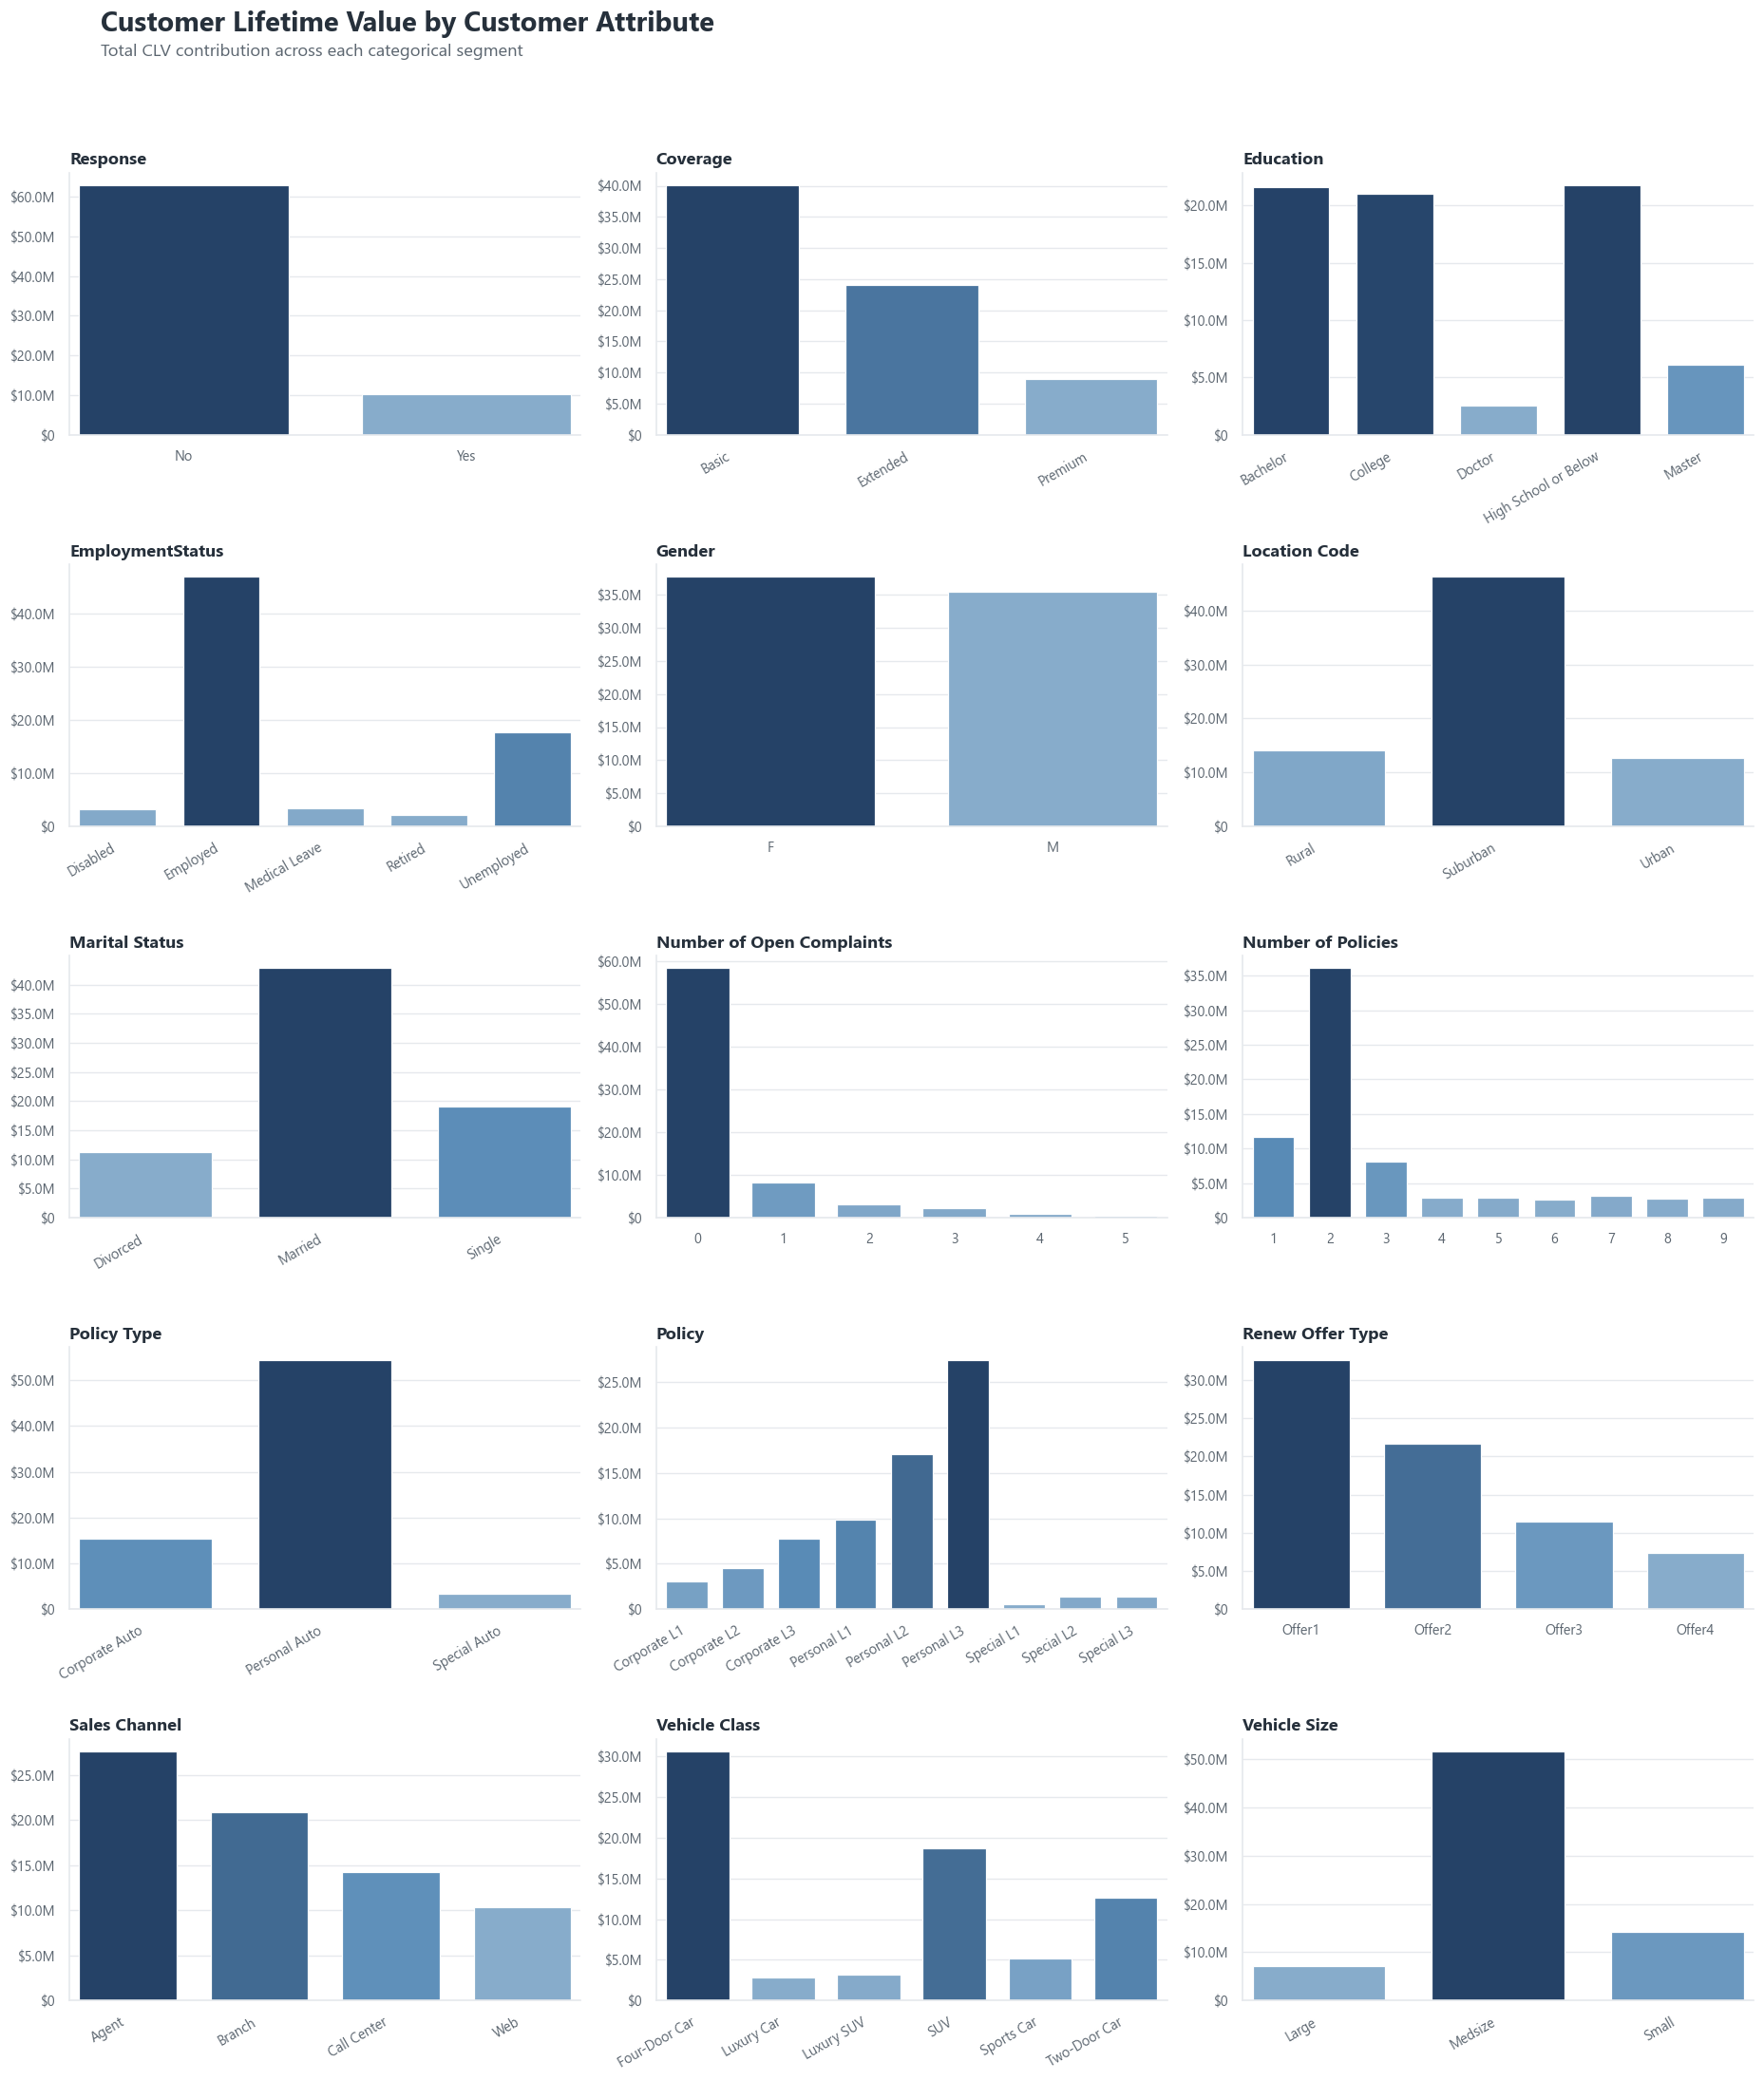

In [6]:
fig, axes = plt.subplots(5, 3, figsize=(17, 20))
fig.suptitle("Customer Lifetime Value by Customer Attribute",
             x=0.06, y=0.994, ha="left", fontsize=19, fontweight="bold", color=INK)
fig.text(0.06, 0.972, "Total CLV contribution across each categorical segment",
         ha="left", fontsize=12, color=MUTED)

for k, ax in enumerate(axes.flat):
    col = cat_cols[k]
    totals = df_clean.groupby(col, observed=True)["Customer Lifetime Value"].sum()
    norm = (totals - totals.min()) / (totals.max() - totals.min() + 1e-9)
    ax.bar(range(len(totals)), totals.values, width=0.74, edgecolor="white",
           linewidth=0.8, color=SEQ_NAVY(0.35 + 0.6 * norm.values))
    ax.set_xticks(range(len(totals)))
    labels = [str(t) for t in totals.index]
    rot = 30 if max(len(l) for l in labels) > 6 else 0
    ax.set_xticklabels(labels, rotation=rot, ha="right" if rot else "center")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(money))
    ax.set_title(col, loc="left", fontsize=12)
    ax.margins(x=0.02)

fig.tight_layout(rect=(0, 0, 1, 0.955))
fig.savefig("./CLV_hist.jpg")
plt.show()

**What the segments reveal**

- State contribution is fairly uniform — geography alone is a weak CLV driver.
- Customers who **did not** respond to the email campaign still show higher total CLV than those who did.
- CLV by coverage follows the expected pattern: **Basic > Extended > Premium** (Basic is the largest book).
- **Doctorate** and **Master** holders contribute the least CLV.
- Value concentrates in **Employed** and **Unemployed** customers, splits evenly across gender.
- **Suburban** locations and **Married** customers carry the highest CLV.
- High CLV is associated with **zero open complaints**.

In [7]:
from sklearn import preprocessing

# Min-max scale CLV so segment contributions are comparable on one color scale
x = df_clean.copy()
scaler = preprocessing.MinMaxScaler()
x["Customer Lifetime Value"] = scaler.fit_transform(
    x["Customer Lifetime Value"].values.reshape(-1, 1))

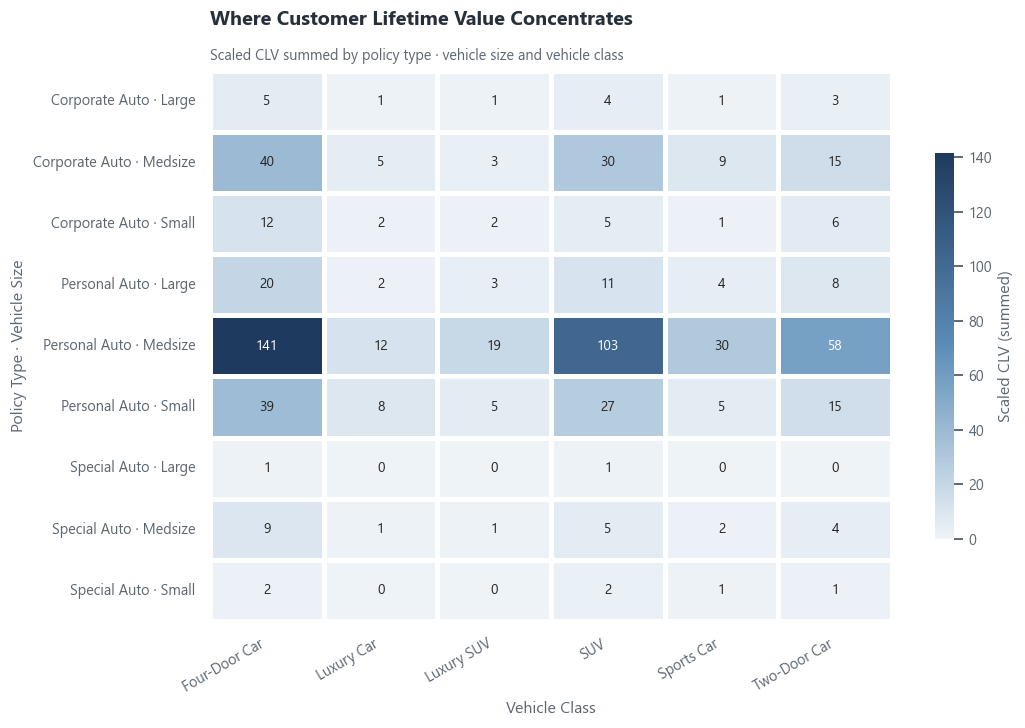

In [8]:
table = pd.pivot_table(x, values="Customer Lifetime Value",
                       index=["Policy Type", "Vehicle Size"],
                       columns="Vehicle Class", aggfunc="sum", fill_value=0)
table.index = [" · ".join(map(str, t)) for t in table.index]

fig, ax = plt.subplots(figsize=(10, 6.5))
sns.heatmap(table, annot=True, fmt=".0f", cmap=SEQ_NAVY, linewidths=2, linecolor="white",
            cbar_kws={"label": "Scaled CLV (summed)", "shrink": 0.7},
            annot_kws={"size": 9}, ax=ax)
titles(ax, "Where Customer Lifetime Value Concentrates",
       "Scaled CLV summed by policy type · vehicle size and vehicle class")
ax.set_xlabel("Vehicle Class"); ax.set_ylabel("Policy Type · Vehicle Size")
ax.tick_params(left=False, bottom=False)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.savefig("./CLV_contribution.png")
plt.show()

#### Insights — CLV contribution

**Key findings**

- **Personal Auto · Medsize** is by far the most valuable segment, dominating overall CLV.
- **Personal Auto · Small** and **Corporate Auto · Medsize** are the next strongest contributors.
- **Special Auto** segments contribute very little value across every vehicle class.
- Within vehicle class, **Four-Door Car** and **SUV** lead; luxury and sports classes are niche.

**Recommendations**

- Prioritize acquisition and retention in the **Personal Auto · Medsize** and **Corporate Auto · Medsize** segments.
- Tailor products and pricing for the under-performing **Special Auto** segments.
- Pair this value map with the churn analysis below to protect the most valuable cohorts.

### Campaign Response

Repeating the segment view, this time counting customers who answered **Yes** to the
new-policy offer.

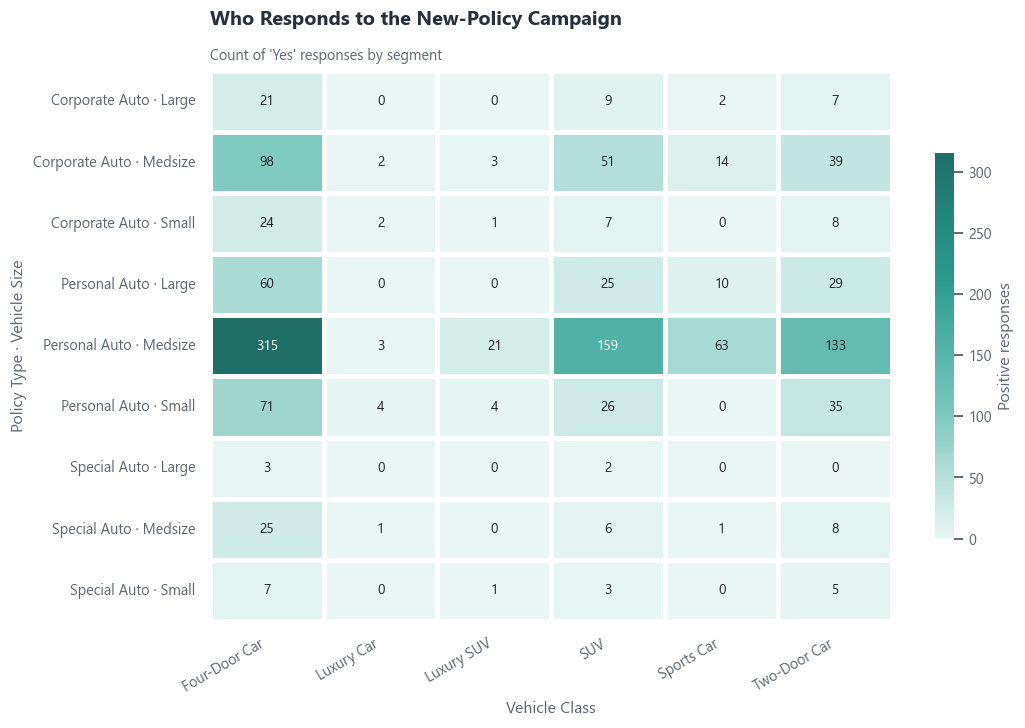

In [9]:
table2 = pd.pivot_table(x[x["Response"] == "Yes"], values="Response",
                        index=["Policy Type", "Vehicle Size"],
                        columns="Vehicle Class", aggfunc="count", fill_value=0)
table2.index = [" · ".join(map(str, t)) for t in table2.index]

fig, ax = plt.subplots(figsize=(10, 6.5))
sns.heatmap(table2, annot=True, fmt=".0f", cmap=SEQ_TEAL, linewidths=2, linecolor="white",
            cbar_kws={"label": "Positive responses", "shrink": 0.7},
            annot_kws={"size": 9}, ax=ax)
titles(ax, "Who Responds to the New-Policy Campaign",
       "Count of 'Yes' responses by segment")
ax.set_xlabel("Vehicle Class"); ax.set_ylabel("Policy Type · Vehicle Size")
ax.tick_params(left=False, bottom=False)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.savefig("./Response.png")
plt.show()

#### Insights — campaign response

- **Personal Auto · Medsize** is again the most responsive segment, leading every vehicle class.
- **Corporate Auto** responds less than Personal Auto; **Special Auto** responds least of all.
- **Four-Door Car** and **SUV** drive the bulk of positive responses.
- Response and value concentrate in the **same** segments — campaign spend can be focused tightly.

**Recommendation:** Concentrate marketing on **Personal Auto · Medsize** (Four-Door / SUV) and
re-evaluate offers for the low-response Special Auto segments.

## 4 · Churn Analysis — Survival & Hazard

Using `Months Since Policy Inception` as the timeline, we reconstruct a survival curve from
first principles:

- **Retention** — customers still active at each month.
- **Hazard** — share of the remaining base that lapses in a given month.
- **Survival** — cumulative probability of remaining a customer.

In [10]:
# Customers reaching each tenure (months), ordered along the timeline
df_churn = (df_clean["Months Since Policy Inception"].value_counts()
            .sort_index().rename("Stopped").to_frame())
total_customers = df_churn["Stopped"].sum()

# Retention: base remaining at the start of each month
retention = [total_customers]
for i in range(1, len(df_churn)):
    retention.append(retention[i - 1] - df_churn["Stopped"].iloc[i - 1])
df_churn["Retention"] = pd.Series(retention, index=df_churn.index)

# Hazard: lapse rate of the remaining base; Survival: cumulative product of (1 - hazard)
df_churn["Hazard"] = df_churn["Stopped"] / df_churn["Retention"]
survival = [1.0]
for i in range(1, len(df_churn)):
    survival.append(survival[i - 1] * (1 - df_churn["Hazard"].iloc[i - 1]))
df_churn["Survival"] = pd.Series(survival, index=df_churn.index)

df_churn.head(3)

,Stopped,Retention,Hazard,Survival
Months Since Policy Inception,,,,
0,83,9134,0.009087,1.000000
1,85,9051,0.009391,0.990913
2,89,8966,0.009926,0.981607


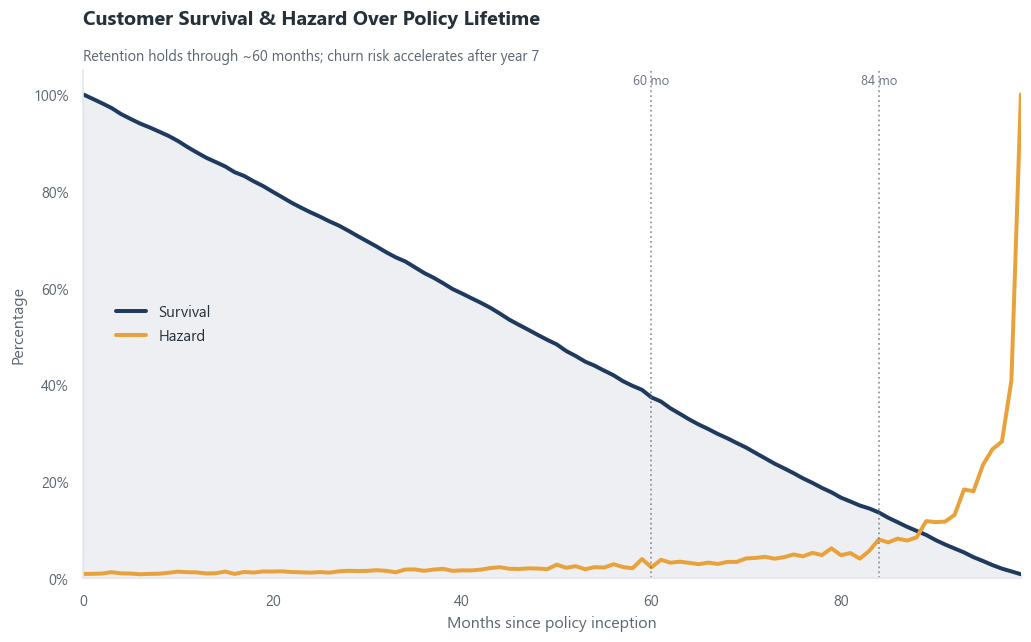

In [11]:
months = df_churn.index.to_numpy()

fig, ax = plt.subplots(figsize=(11, 6))
ax.fill_between(months, df_churn["Survival"] * 100, color=NAVY, alpha=0.08)
ax.plot(months, df_churn["Survival"] * 100, color=NAVY, lw=2.6, label="Survival")
ax.plot(months, df_churn["Hazard"] * 100, color=AMBER, lw=2.6, label="Hazard")

for m in (60, 84):
    ax.axvline(m, color=SLATE, ls=":", lw=1.2, alpha=0.7)
    ax.text(m, 102, f"{m} mo", color=SLATE, fontsize=8.5, ha="center")

ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, months.max()); ax.set_ylim(0, 105)
ax.grid(axis="y")
titles(ax, "Customer Survival & Hazard Over Policy Lifetime",
       "Retention holds through ~60 months; churn risk accelerates after year 7")
ax.set_xlabel("Months since policy inception"); ax.set_ylabel("Percentage")
ax.legend(loc="center left", bbox_to_anchor=(0.02, 0.5))
fig.savefig("./hazard_survival_churn_analysis.png")
plt.show()

##### Observations

Hazard stays low and stable through roughly **60 months (5 years)** — consistent with the
popularity of 5-year coverage terms. After 60 months hazard rises gradually, then climbs
sharply around **80–84 months (~7 years)**.

A plausible story: customers renew after the initial 5-year term for a 2-year extension
(reaching ~7 years), then sell the vehicle — a common ownership horizon — and let the policy lapse.

**Overall assessment**

- **Effective retention** through the first 5–7 years (steady survival, low hazard).
- **Renewal challenge** at the ~7-year mark, where hazard spikes.
- **Behavioral signal:** vehicle turnover around year 7 appears to drive late-stage churn.

## 5 · Predictive Modeling

Before modeling, we inspect numeric relationships and treat extreme values.

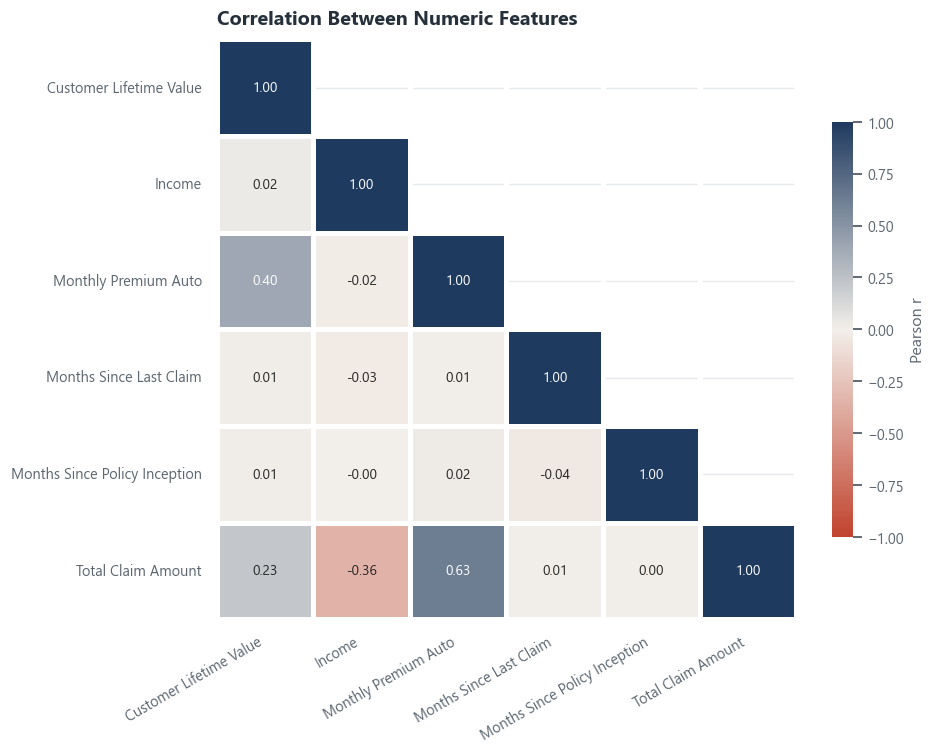

In [12]:
corr = df_clean[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=DIVERGE, vmin=-1, vmax=1,
            center=0, square=True, linewidths=2, linecolor="white",
            cbar_kws={"label": "Pearson r", "shrink": 0.7}, annot_kws={"size": 9}, ax=ax)
titles(ax, "Correlation Between Numeric Features")
ax.tick_params(left=False, bottom=False)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.show()

The strongest relationships are **Income ↔ Total Claim Amount** and
**Monthly Premium ↔ Total Claim Amount** — worth keeping in mind, though the correlations
are moderate rather than severe. We retain all numeric features.

In [13]:
df_clean[["Total Claim Amount", "Income", "Monthly Premium Auto"]].describe()

,Total Claim Amount,Income,Monthly Premium Auto
count,9134.000000,9134.000000,9134.000000
mean,434.088794,37657.380009,93.219291
std,290.500092,30379.904734,34.407967
min,0.099007,0.000000,61.000000
25%,272.258244,0.000000,68.000000
50%,383.945434,33889.500000,83.000000
75%,547.514839,62320.000000,109.000000
max,2893.239678,99981.000000,298.000000


**Outlier treatment.** The numeric features sit on very different scales, so we view them on a
log axis. We trim only the extreme upper tail of **Customer Lifetime Value** (above
`Q3 + 1.5 · IQR`); these very-high-value customers behave differently and are better modeled
as their own cohort.

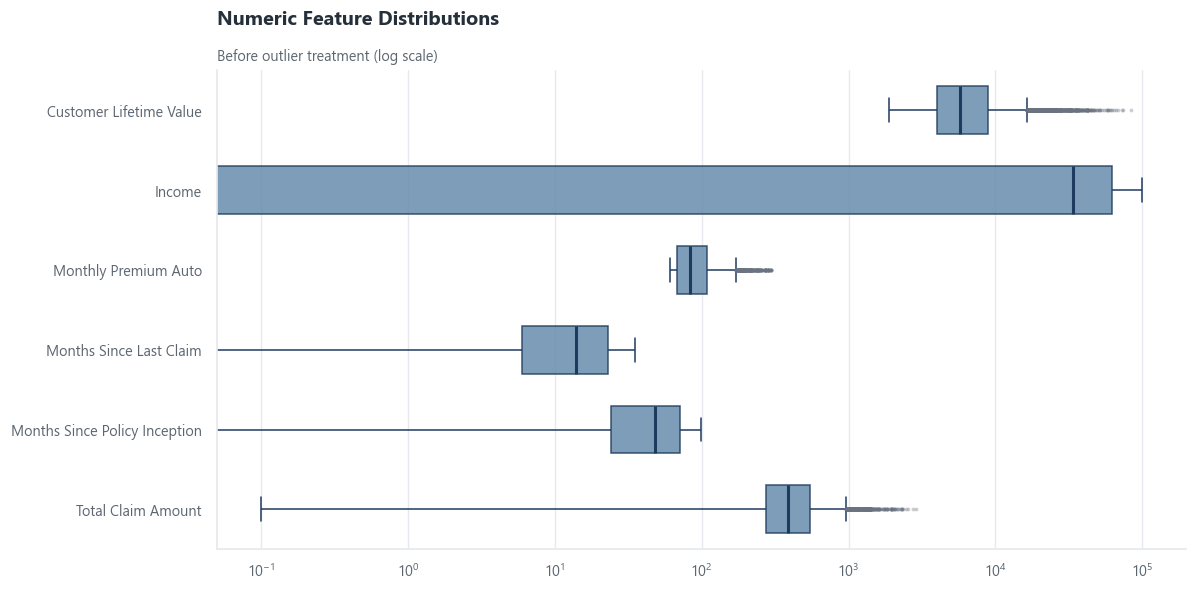

In [14]:
def distribution_box(frame, subtitle):
    fig, ax = plt.subplots(figsize=(11, 5.5))
    sns.boxplot(data=frame[num_cols], orient="h", ax=ax, color=LBLUE, width=0.6,
                fliersize=2.5,
                flierprops=dict(marker="o", markerfacecolor=SLATE,
                                markeredgecolor="none", alpha=0.35),
                medianprops=dict(color=NAVY, lw=2), boxprops=dict(edgecolor=NAVY, alpha=0.85),
                whiskerprops=dict(color=NAVY), capprops=dict(color=NAVY))
    ax.set_xscale("log"); ax.grid(axis="x")
    titles(ax, "Numeric Feature Distributions", subtitle)
    fig.tight_layout()
    return fig

df_reg = df_clean.copy()
distribution_box(df_reg, "Before outlier treatment (log scale)")
plt.show()

Rows: 9,134 -> 8,317 (817 high-CLV outliers removed)


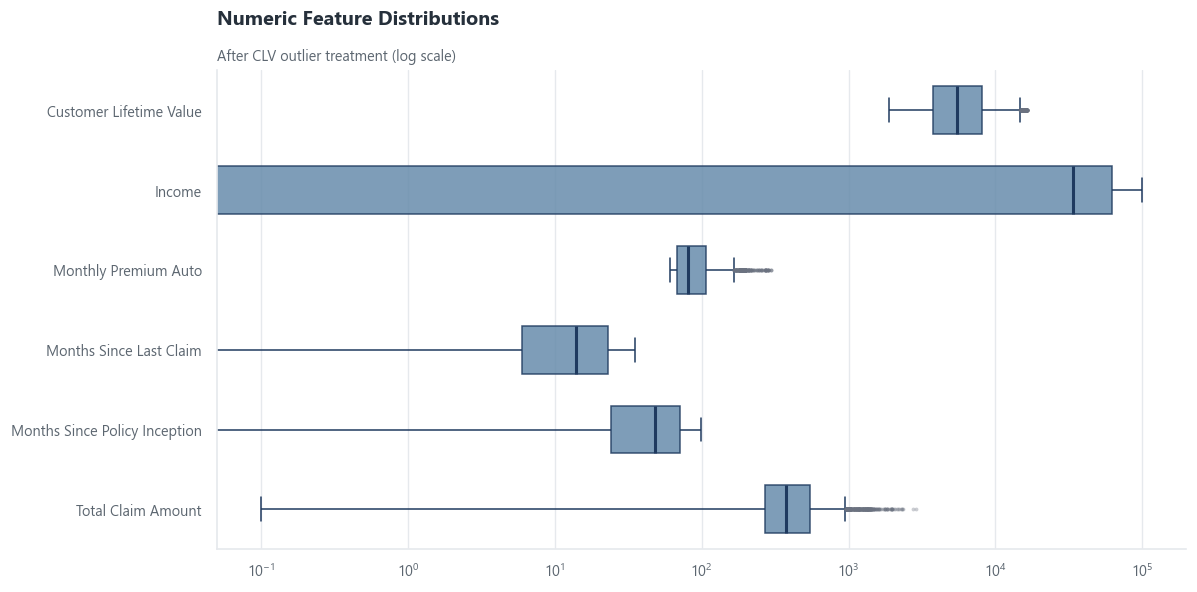

In [15]:
# Trim the extreme upper tail of CLV using the 1.5 * IQR rule
df_reg_or = df_reg.copy()
for col in ["Customer Lifetime Value"]:
    q1, q3 = df_reg[col].quantile(0.25), df_reg[col].quantile(0.75)
    upper = q3 + 1.5 * (q3 - q1)
    df_reg_or = df_reg_or[df_reg_or[col] < upper]

print(f"Rows: {len(df_reg):,} -> {len(df_reg_or):,} "
      f"({len(df_reg) - len(df_reg_or):,} high-CLV outliers removed)")
distribution_box(df_reg_or, "After CLV outlier treatment (log scale)")
plt.show()

### 5.1 · Predicting Customer Lifetime Value (Regression)

We build a single preprocessing pipeline (standardize numerics, one-hot encode categoricals),
then benchmark a panel of regressors and tune the tree-based and instance-based models.

In [16]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             mean_absolute_percentage_error)
from time import time

In [17]:
train_df, test_df = train_test_split(df_reg_or, test_size=0.2, random_state=42)

# Scale numerics + one-hot encode categoricals in one transformer
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols)])

train_t = preprocessor.fit_transform(train_df)
test_t = preprocessor.transform(test_df)
to_dense = lambda m: m.toarray() if hasattr(m, "toarray") else m
feature_names = preprocessor.get_feature_names_out()

train_tdf = pd.DataFrame(to_dense(train_t), columns=feature_names)
test_tdf = pd.DataFrame(to_dense(test_t), columns=feature_names)

# Target = (unscaled) CLV; exclude the scaled CLV column and the response label from features
drop_cols = ["num__Customer Lifetime Value", "cat__Response_Yes"]
X_train = train_tdf.drop(drop_cols, axis=1)
y_train = train_df["Customer Lifetime Value"]
X_test = test_tdf.drop(drop_cols, axis=1)
y_test = test_df["Customer Lifetime Value"]

X_train.shape, X_test.shape

((6653, 56), (1664, 56))

In [18]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "SVR": SVR(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
}

# Baseline benchmark (default hyperparameters)
rows = {}
for name, model in models.items():
    t0 = time()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows[name] = {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R²": r2_score(y_test, pred),
        "MAPE": mean_absolute_percentage_error(y_test, pred),
        "Time (s)": time() - t0,
    }

baseline_df = pd.DataFrame(rows).T.sort_values("R²", ascending=False)
(baseline_df.style
    .format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R²": "{:.3f}",
             "MAPE": "{:.1%}", "Time (s)": "{:.2f}"})
    .background_gradient(cmap=SEQ_TEAL, subset=["R²"])
    .set_caption("Baseline regression performance (default hyperparameters)"))

,MAE,RMSE,R²,MAPE,Time (s)
Random Forest,328,862,0.931,3.9%,4.47
Gradient Boosting,582,965,0.913,9.1%,1.08
Lasso Regression,683,"1,047",0.898,11.2%,0.02
Linear Regression,687,"1,049",0.898,11.4%,0.03
Ridge Regression,685,"1,049",0.897,11.3%,0.01
KNN,"1,764","2,446",0.442,29.3%,2.81
SVR,"2,526","3,379",-0.064,43.3%,3.14


In [19]:
# Search spaces for the models worth tuning
param_grids = {
    "Random Forest": {"n_estimators": [100, 250], "max_depth": [None, 10],
                      "min_samples_split": [2, 5]},
    "SVR": {"kernel": ["linear", "rbf"], "C": [1, 10]},
    "Gradient Boosting": {"n_estimators": [100, 250], "learning_rate": [0.01, 0.1],
                          "max_depth": [5]},
    "KNN": {"n_neighbors": [3, 5], "weights": ["uniform", "distance"]},
}

In [20]:
tuned = {}
for name, model in models.items():
    t0 = time()
    if name in param_grids:
        search = RandomizedSearchCV(model, param_grids[name], n_iter=8,
                                    scoring="neg_mean_absolute_error", cv=2,
                                    n_jobs=-1, random_state=42)
        search.fit(X_train, y_train)
        best, params = search.best_estimator_, search.best_params_
    else:
        model.fit(X_train, y_train)
        best, params = model, None
    pred = best.predict(X_test)
    tuned[name] = {
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mean_squared_error(y_test, pred),
        "R²": r2_score(y_test, pred),
        "Training Time (s)": time() - t0,
        "Best Params": params,
    }

best_results_df = pd.DataFrame(tuned).T.sort_values("R²", ascending=False)
(best_results_df[["MAE", "MSE", "R²", "Training Time (s)"]].style
    .format({"MAE": "{:,.0f}", "MSE": "{:,.0f}", "R²": "{:.3f}",
             "Training Time (s)": "{:.2f}"})
    .background_gradient(cmap=SEQ_TEAL, subset=["R²"])
    .set_caption("Tuned regression performance"))

,MAE,MSE,R²,Training Time (s)
Random Forest,326,"738,964",0.931,30.47
Gradient Boosting,333,"742,086",0.931,8.88
Lasso Regression,683,"1,096,165",0.898,0.01
Linear Regression,687,"1,099,508",0.898,0.02
Ridge Regression,685,"1,100,186",0.897,0.01
SVR,803,"1,821,427",0.830,5.73
KNN,"1,724","5,883,219",0.452,0.54


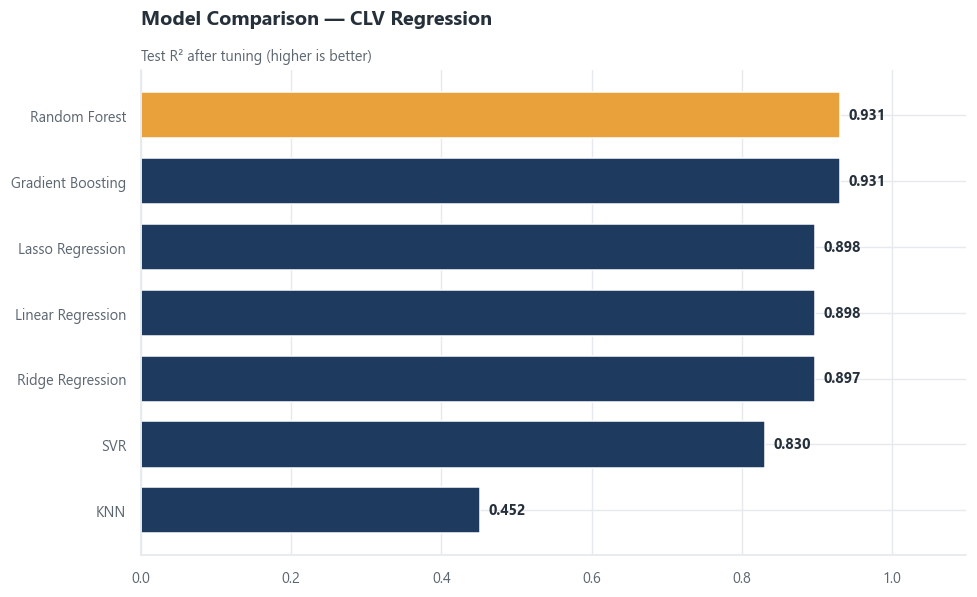

In [21]:
hbar_ranking(best_results_df["R²"],
             "Model Comparison — CLV Regression",
             "Test R² after tuning (higher is better)")
plt.show()

**Tree-based models win.** Random Forest and Gradient Boosting explain ~93% of CLV variance
and post the lowest error, comfortably ahead of the linear and instance-based baselines.

### 5.2 · Predicting Campaign Response (Classification)

Reusing the same encoded features, we now predict whether a customer responds **Yes** to the
new-policy offer.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

# Target = response label; features = everything else
Xc_train = train_tdf.drop("cat__Response_Yes", axis=1)
yc_train = train_tdf["cat__Response_Yes"]
Xc_test = test_tdf.drop("cat__Response_Yes", axis=1)
yc_test = test_tdf["cat__Response_Yes"]

In [23]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
}

clf_rows, conf_mats = {}, {}
for name, model in classifiers.items():
    t0 = time()
    model.fit(Xc_train, yc_train)
    pred = model.predict(Xc_test)
    clf_rows[name] = {
        "Accuracy": accuracy_score(yc_test, pred),
        "Precision": precision_score(yc_test, pred, zero_division=0),
        "Recall": recall_score(yc_test, pred, zero_division=0),
        "F1": f1_score(yc_test, pred, zero_division=0),
        "Time (s)": time() - t0,
    }
    conf_mats[name] = confusion_matrix(yc_test, pred)

clf_df = pd.DataFrame(clf_rows).T.sort_values("F1", ascending=False)
(clf_df.style
    .format({"Accuracy": "{:.3f}", "Precision": "{:.3f}", "Recall": "{:.3f}",
             "F1": "{:.3f}", "Time (s)": "{:.2f}"})
    .background_gradient(cmap=SEQ_TEAL, subset=["F1"])
    .set_caption("Response classification performance"))

,Accuracy,Precision,Recall,F1,Time (s)
Random Forest,0.996,0.970,1.000,0.985,0.70
SVM,0.888,0.785,0.229,0.354,5.97
Gradient Boosting,0.887,0.857,0.188,0.309,1.35
Logistic Regression,0.872,0.593,0.143,0.231,0.08


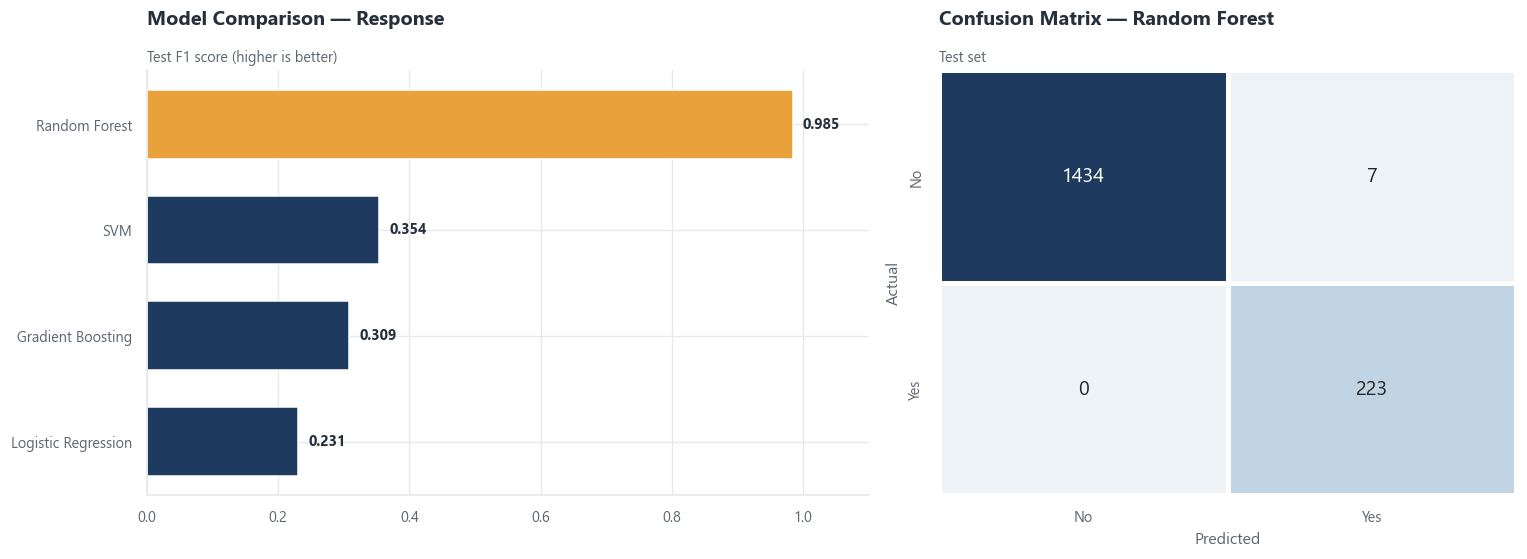

In [24]:
best_clf = clf_df.index[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2),
                               gridspec_kw={"width_ratios": [1.25, 1]})

# Left: F1 ranking across classifiers
order = clf_df.sort_values("F1")
colors = [NAVY] * len(order); colors[-1] = AMBER
ax1.barh(range(len(order)), order["F1"], color=colors, edgecolor="white", height=0.65)
ax1.set_yticks(range(len(order))); ax1.set_yticklabels(order.index)
ax1.set_xlim(0, 1.1); ax1.grid(axis="x")
for i, v in enumerate(order["F1"]):
    ax1.text(v + 0.015, i, f"{v:.3f}", va="center", fontsize=9.5,
             color=INK, fontweight="bold")
titles(ax1, "Model Comparison — Response", "Test F1 score (higher is better)")

# Right: confusion matrix for the best model
cm = conf_mats[best_clf]
sns.heatmap(cm, annot=True, fmt="d", cmap=SEQ_NAVY, cbar=False, linewidths=2,
            linecolor="white", annot_kws={"size": 13}, ax=ax2,
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
titles(ax2, f"Confusion Matrix — {best_clf}", "Test set")
ax2.set_xlabel("Predicted"); ax2.set_ylabel("Actual")
ax2.tick_params(left=False, bottom=False)

fig.tight_layout()
plt.show()

**Random Forest is the standout**, achieving the highest F1 and near-perfect separation of
responders. Logistic Regression and SVM reach high accuracy but miss most positive responders
(low recall) — a reminder that accuracy alone is misleading on imbalanced response data.

## 6 · Conclusion & Key Takeaways

| Area | Takeaway |
|---|---|
| **Value concentration** | `Personal Auto · Medsize` (Four-Door & SUV) drives the majority of CLV. |
| **Retention** | Survival is strong for 5–7 years; hazard spikes near month 84 (~7 years). |
| **Targeting** | Response and value share the same segments — campaign spend can be focused tightly. |
| **CLV prediction** | Random Forest / Gradient Boosting explain ~93% of CLV variance (R² ≈ 0.93). |
| **Response prediction** | Random Forest gives the best F1 for identifying likely responders. |

**Recommended actions**

1. Protect and grow the high-value `Personal Auto · Medsize` book.
2. Launch proactive renewal outreach **before** the ~7-year churn cliff.
3. Use the Random Forest response model to focus marketing on likely responders.
4. Treat ultra-high-CLV customers as a distinct, separately modeled cohort.

## References

- [Customer Lifetime Value — Kaggle](https://www.kaggle.com/code/sittakonphommee/customer-lifetime-value)
- [Customer Lifetime Value (lab) — Kaggle](https://www.kaggle.com/code/putanyn/660632067-3rd-lab-customer-lifetime-value#Algorithm-Implementation)